In [17]:
# OneR算法实现
import numpy as np
from sklearn.datasets import load_iris
# 加载iris数据集
dataset = load_iris()

print(dataset.DESCR)


.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [18]:
# 加载iris数据集中的data数组（数据集的特征）
X = dataset.data
# 加载iris数据集中的target数组（数据集的类别）
y_true = dataset.target
# 计算每一项特征的平均值
attribute_means = X.mean(axis=0)
# 与平均值比较，大于等于的为“1”，小于的为“0”.将连续性的特征值变为离散性的类别型。
x = np.array(X >= attribute_means, dtype="int")

n_samples, n_features = X.shape

print(n_samples, n_features)

150 4


In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y_true, random_state=14)

In [6]:
from operator import itemgetter
from collections import defaultdict
# 找到一个特征下特定值对应的最可能类别及错误数
def train_feature_class(x, y_true, feature_index, feature_values):
    num_class = defaultdict(int)
    for sample, y in zip(x, y_true):
        if sample[feature_index] == feature_values:
            num_class[y] += 1
    # 按类别出现次数排序，找出最频繁的类别
    sorted_num_class = sorted(num_class.items(), key=itemgetter(1), reverse=True)  # 修正itemgetter参数错误
    most_frequent_class = sorted_num_class[0][0]
    # 计算错误数（非最频繁类别的样本数总和）
    error = sum(value_num for class_num, value_num in sorted_num_class if class_num != most_frequent_class)
    return most_frequent_class, error

In [7]:
# 训练单个特征，返回该特征下各值的预测类别及总错误数
def train_feature(x, y_true, feature_index):
    n_sample, n_feature = x.shape
    assert 0 <= feature_index < n_feature
    values = set(x[:, feature_index])  # 该特征的所有可能值
    predictors = {}
    errors = []
    for current_value in values:
        most_frequent_class, error = train_feature_class(x, y_true, feature_index, current_value)
        predictors[current_value] = most_frequent_class
        errors.append(error)
    total_error = sum(errors)
    return predictors, total_error

In [19]:
# 找到所有特征下的各特征值的类别，格式就如：{0：({0: 0, 1: 2}, 41)}首先为一个字典，字典的键是某个特征，字典的值由一个集合构成，这个集合又是由一个字典和一个值组成，字典的键是特征值，字典的值为类别，最后一个单独的值是错误率。
all_predictors = {feature: train_feature(x_train, y_train, feature) for feature in range(x_train.shape[1])}
print(all_predictors)

{0: ({np.int64(0): np.int64(0), np.int64(1): np.int64(2)}, 41), 1: ({np.int64(0): np.int64(1), np.int64(1): np.int64(0)}, 58), 2: ({np.int64(0): np.int64(0), np.int64(1): np.int64(2)}, 37), 3: ({np.int64(0): np.int64(0), np.int64(1): np.int64(2)}, 37)}


In [9]:
# 筛选出每个特征下的错误率出来
errors = {feature: error for feature, (mapping, error) in all_predictors.items()}

In [10]:
# 找到错误率最低的最佳特征
best_feature, best_error = sorted(errors.items(), key=itemgetter(1), reverse=False)[0]
print(f"The best model is based on feature {best_feature} and has error {best_error:.2f}")
print("Best feature mapping:", all_predictors[best_feature][0])

The best model is based on feature 2 and has error 37.00
Best feature mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(2)}


In [11]:
# 建立模型
model = {"feature": best_feature, "predictor": all_predictors[best_feature][0]}

In [12]:
# 预测函数
def predict(x_test, model):
    feature = model["feature"]
    predictor = model["predictor"]
    y_predict = np.array([predictor[int(sample[feature])] for sample in x_test])
    return y_predict

In [13]:
# 测试模型
y_predict = predict(x_test, model)

In [14]:
# 计算准确率
accuracy = np.mean(y_predict == y_test) * 100
print(f"The test accuracy is {accuracy:.2f}%")

The test accuracy is 65.79%


In [15]:
from sklearn.metrics import classification_report

# 输出分类报告
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        17
           1       0.00      0.00      0.00        13
           2       0.40      1.00      0.57         8

    accuracy                           0.66        38
   macro avg       0.45      0.67      0.51        38
weighted avg       0.51      0.66      0.55        38



D:\Anaconda3\Anaconda\envs\lisc\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda3\Anaconda\envs\lisc\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda3\Anaconda\envs\lisc\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


在测试集中存在某些类别（标签）没有被模型预测到（即模型从未输出该类别），导致精确率（precision）计算时出现分母为 0 的情况（TP + FP = 0），scikit-learn 无法计算该类别的精确率，只能默认设为 0.0 并发出警告。

明确指定当出现 “无预测样本的类别” 时如何处理（通常设为 0 或 1）

In [16]:
# 输出分类报告时添加 zero_division 参数
print(classification_report(y_test, y_predict, zero_division=1))  # 或 zero_division=0

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        17
           1       1.00      0.00      0.00        13
           2       0.40      1.00      0.57         8

    accuracy                           0.66        38
   macro avg       0.78      0.67      0.51        38
weighted avg       0.85      0.66      0.55        38



模型准确率: 59.09%


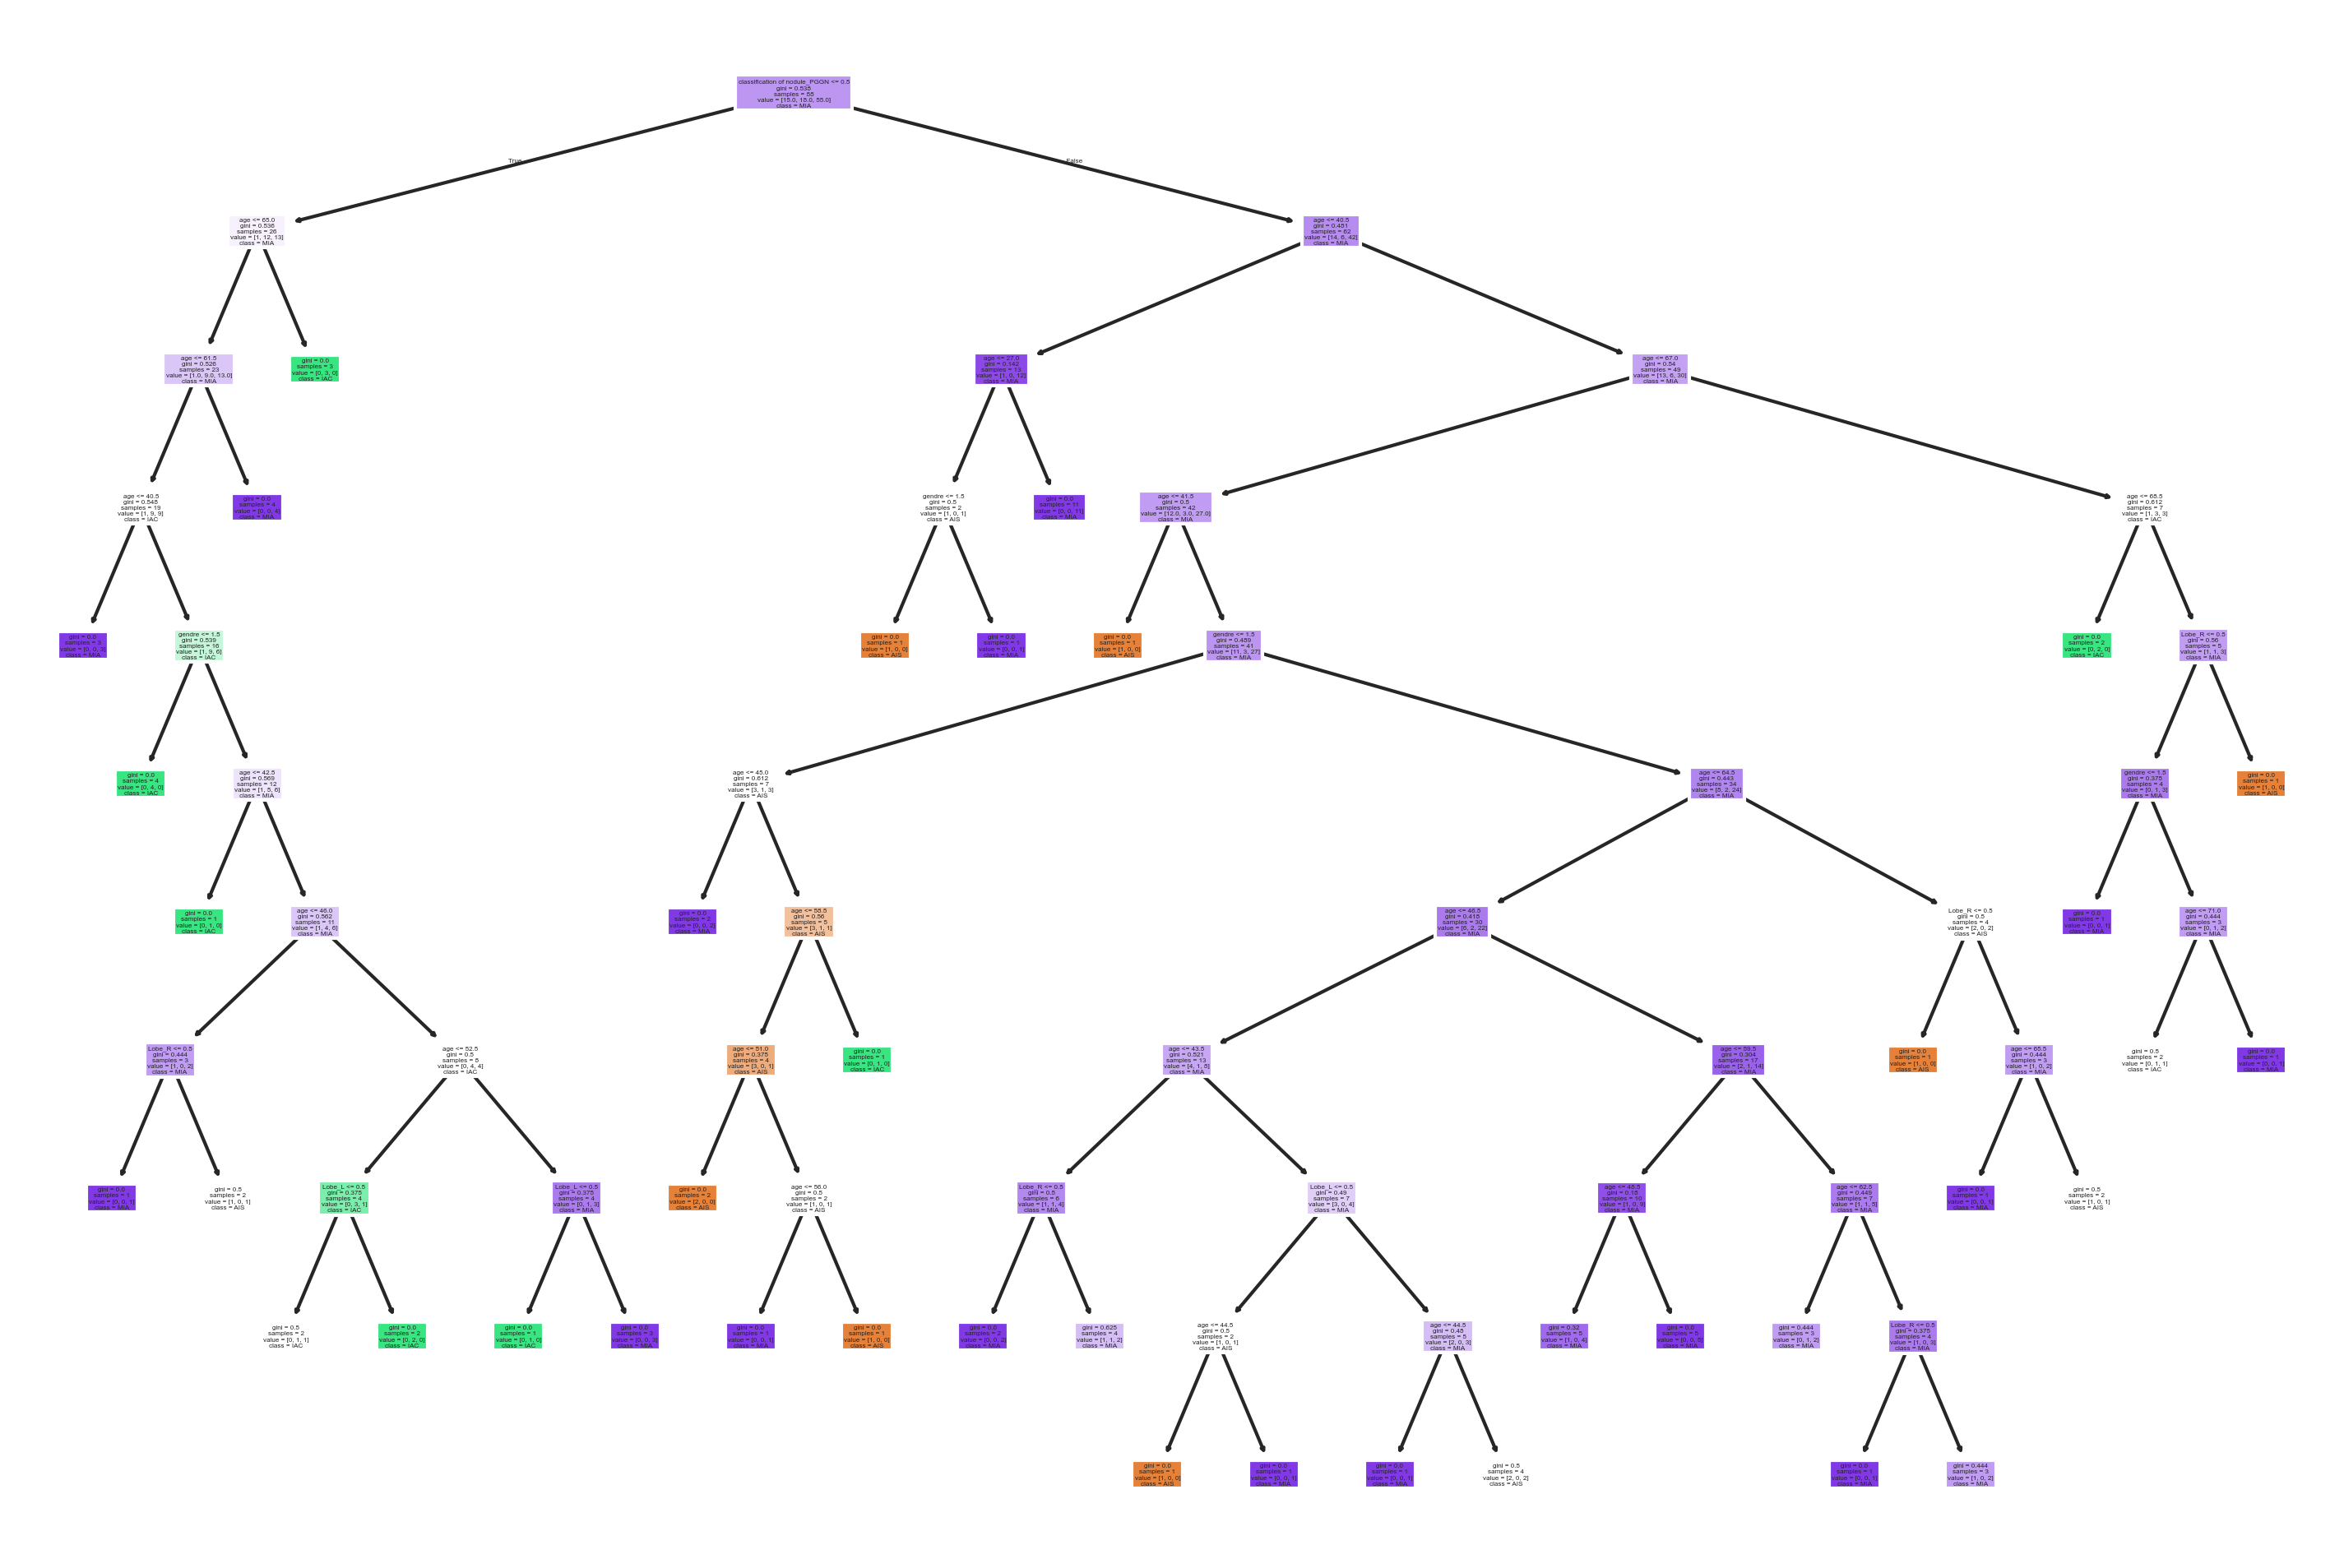


决策树规则:
如果 (classification of nodule_PGGN <= 0.5) & (age <= 65.0) & (age <= 61.5) & (age <= 40.5), 那么 病灶类型为 MIA
如果 (classification of nodule_PGGN <= 0.5) & (age <= 65.0) & (age <= 61.5) & (age > 40.5) & (gendre <= 1.5), 那么 病灶类型为 IAC
如果 (classification of nodule_PGGN <= 0.5) & (age <= 65.0) & (age <= 61.5) & (age > 40.5) & (gendre > 1.5) & (age <= 42.5), 那么 病灶类型为 IAC
如果 (classification of nodule_PGGN <= 0.5) & (age <= 65.0) & (age <= 61.5) & (age > 40.5) & (gendre > 1.5) & (age > 42.5) & (age <= 46.0) & (Lobe_R <= 0.5), 那么 病灶类型为 MIA
如果 (classification of nodule_PGGN <= 0.5) & (age <= 65.0) & (age <= 61.5) & (age > 40.5) & (gendre > 1.5) & (age > 42.5) & (age <= 46.0) & (Lobe_R > 0.5), 那么 病灶类型为 AIS
如果 (classification of nodule_PGGN <= 0.5) & (age <= 65.0) & (age <= 61.5) & (age > 40.5) & (gendre > 1.5) & (age > 42.5) & (age > 46.0) & (age <= 52.5) & (Lobe_L <= 0.5), 那么 病灶类型为 IAC
如果 (classification of nodule_PGGN <= 0.5) & (age <= 65.0) & (age <= 61.5) & (age > 40.5) & (gendre > 1.5) & (a

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


# 步骤1：加载数据并预处理
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)
    # 选择需要的列
    selected_columns = ['b', 'gendre', 'age', 'classification of nodule', 'Lobe']
    data = data[selected_columns]
    # 处理缺失值
    data = data.dropna()
    # 对分类变量进行编码
    data_encoded = pd.get_dummies(data, columns=['classification of nodule', 'Lobe'])
    return data_encoded


# 步骤2：划分训练集和测试集
def split_data(data_encoded):
    X = data_encoded.drop('b', axis=1)
    y = data_encoded['b']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test


# 步骤3：构建决策树模型并训练
def train_model(X_train, y_train):
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    return clf


# 步骤4：评估模型准确率
def evaluate_model(clf, X_test, y_test):
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"模型准确率: {accuracy * 100:.2f}%")


# 步骤5：可视化决策树
def visualize_tree(clf, feature_names):
    plt.rcParams['figure.dpi'] = 300
    plt.figure(figsize=(12, 8))
    plot_tree(clf, filled=True, feature_names=feature_names, class_names=clf.classes_)
    plt.show()


# 步骤6：从决策树中提取规则
def tree_to_rules(tree, feature_names):
    from sklearn.tree import _tree

    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    def recurse(node, previous_rules):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            left_rules = previous_rules + [f"({name} <= {threshold})"]
            recurse(tree_.children_left[node], left_rules)
            right_rules = previous_rules + [f"({name} > {threshold})"]
            recurse(tree_.children_right[node], right_rules)
        else:
            class_index = np.argmax(tree_.value[node])
            class_label = tree.classes_[class_index]
            rule = " & ".join(previous_rules)
            print(f"如果 {rule}, 那么 病灶类型为 {class_label}")

    recurse(0, [])


if __name__ == "__main__":
    file_path = "C:/Users/21626/Downloads/train.csv" # 请替换为你的文件路径
    data_encoded = load_and_preprocess_data(file_path)
    X_train, X_test, y_train, y_test = split_data(data_encoded)
    clf = train_model(X_train, y_train)
    evaluate_model(clf, X_test, y_test)
    visualize_tree(clf, X_train.columns)
    print("\n决策树规则:")
    tree_to_rules(clf, X_train.columns)